# 1. Data Loading and Cleaning

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
from sklearn.preprocessing import LabelEncoder
import sklearn
from xgboost import XGBRegressor

Melbourne = pd.read_csv("data/MelbourneJune.csv").copy()
Sydney = pd.read_csv("data/SydneyJune.csv").copy()
Brisbane = pd.read_csv("data/BrisbaneJune.csv").copy()
Tasmania = pd.read_csv("data/TasmaniaJune.csv").copy()
WesternAustralia = pd.read_csv("data/WesternAustraliaJune.csv").copy()

In [25]:
major_cities = [Melbourne, Sydney, Brisbane, Tasmania, WesternAustralia]
drop_cols = ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 
             'host_name', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_is_superhost', 'host_picture_url', 
             'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_has_profile_pic', 'neighbourhood', 'neighbourhood_group_cleansed',
            'property_type', 'amenities', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
            'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_last_scraped', 'number_of_reviews_ltm', 'host_identity_verified', 
            'number_of_reviews_l30d', 'has_availability', 'availability_eoy', 'first_review', 'calculated_host_listings_count_entire_homes',
            'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'host_acceptance_rate',
            'reviews_per_month', 'estimated_revenue_l365d', 'license', 'review_scores_accuracy', 'review_scores_cleanliness',
            'review_scores_checkin', 'review_scores_communication', 'review_scores_value', 'last_review', 'bathrooms_text']

for city in major_cities:
    city.dropna(axis = 1, how = 'all', inplace = True) #  Drop columns where EVERY ("ALL") values are missing and edit the dataset 
    city.drop(columns = drop_cols, inplace = True, errors = 'ignore') # Drop columns that are not useful for our analysis
    city['price'] = city['price'].str.replace('$', '').str.replace(',', '').astype(float) # Convert price from string to float for numerical analysis and visualisation
    city.dropna(subset = ['price'], inplace = True) # Drop rows for listings where price does not exists
    city['estimated_revenue'] = city['price'] * city['estimated_occupancy_l365d'] # Estimate revenue for each listing for later comparisons and visualisations
    # This is just an estimated calculation of revenue used by estimated_occupancy across a year (originally from Airbnb's raw data)
    missing_counts = city.isna().sum()

    if 'bedrooms' in city.columns and missing_counts.get('bedrooms', 0) > 100: # There are a lot of missing values in the "bedrooms" column, so we will infer the value from the "accommodates" column divided by 2 (assuming an average of 2 guests per bedroom)
        city['bedrooms'] = city['bedrooms'].fillna(city['accommodates'] // 2) # Impute missing values in the "bedrooms" column by filling them with the value from the "accommodates" column divided by 2 (assuming an average of 2 guests per bedroom)

    if 'beds' in city.columns and missing_counts.get('beds', 0) > 100: 
        city['beds'] = city['beds'].fillna(city['accommodates'] // 2)

    if 'bathrooms' in city.columns and missing_counts.get('bathrooms', 0) > 100: #  Calculate the normal number of bathrooms for each bedroom count and fill the holes with that number.      
        city['bathrooms'] = city['bathrooms'].fillna(city.groupby('bedrooms')['bathrooms'].transform('median'))

major_cities = {"Melbourne": Melbourne, "Sydney": Sydney, "Brisbane": Brisbane, "Tasmania": Tasmania, "Western Australia": WesternAustralia}

for name, df in major_cities.items(): # Add the city name to dataset
    df['city'] = name

combined = pd.concat(major_cities.values(), ignore_index=True) # Combine all the cities into one dataset for easier analysis and visualisation
combined['host_since'] = pd.to_datetime(combined['host_since'])
combined['host_since_year'] = combined['host_since'].dt.year


After removing duplicate and insignificant columns from our city datasets, we observed remaining missing values in key areas such as review_scores for location and ratings, host dates, bedrooms and bathrooms counts. It was not sensible to correct these missing data by filling in the values with 0, as it is both factually introduce and can introduce significant bias into our analysis. Therefore, we have chosen to retain these as Na/NaN values and will utilise functions that automatically exclude them during aggregation or analysis to maintain accuracy. The missing bedrooms and bathrooms values have been dealt with by calculating similar listings with same number of bedrooms and bathrooms and using the median or inferring from the accommodates column to ensure that our estimations remain realistic. Additionally, listings without a price have been removed from our analysis.

# Exploratory Data Analysis

### Price Distribution 

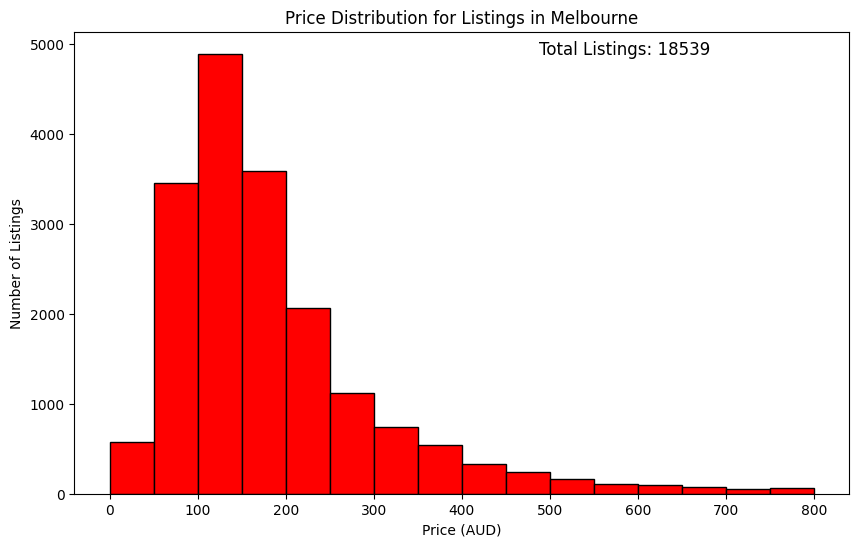

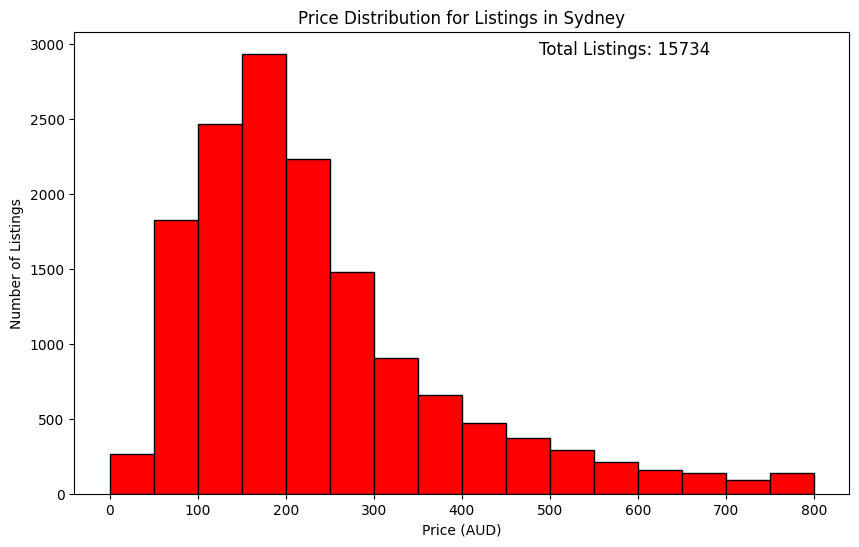

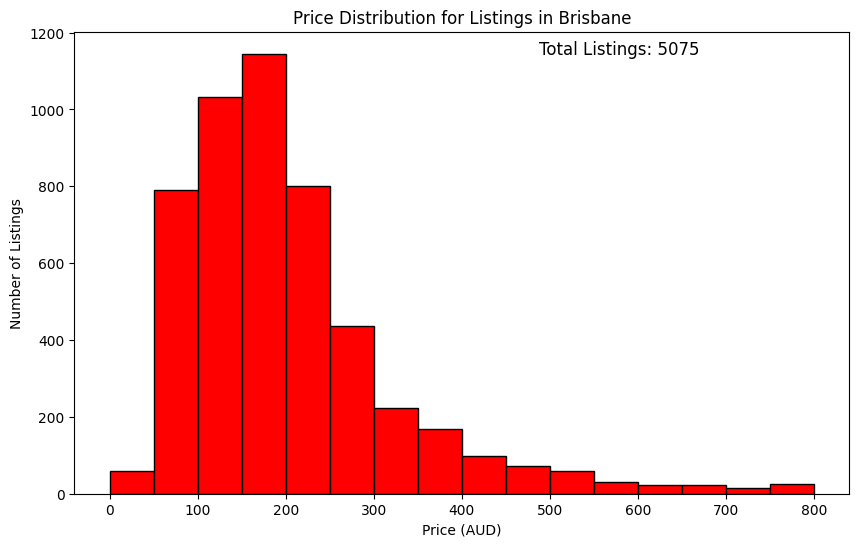

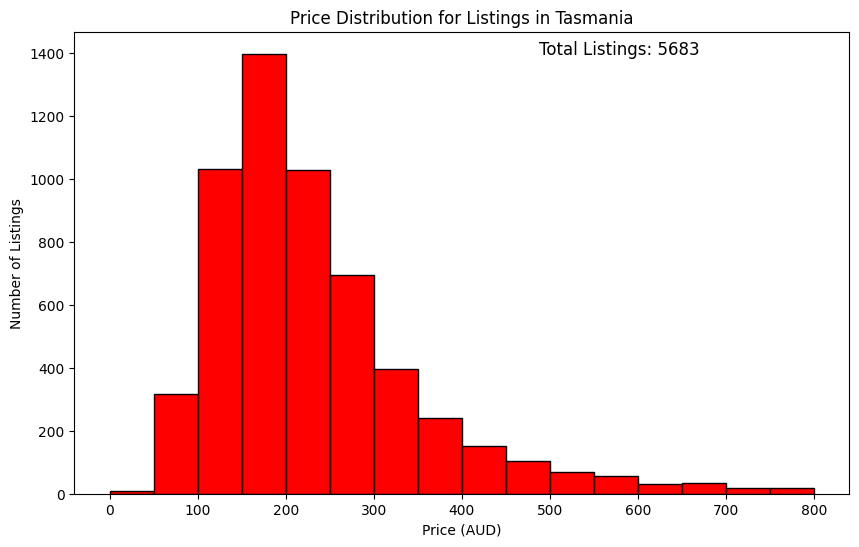

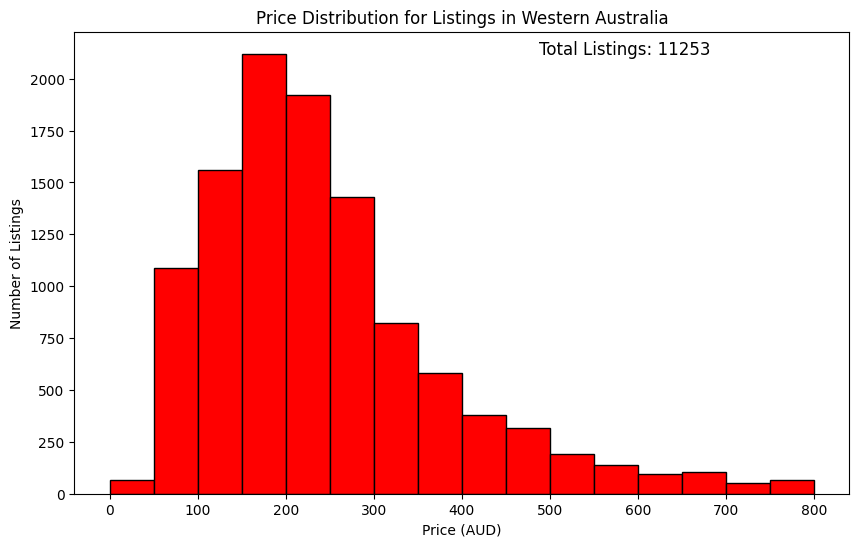

In [26]:
for city_name, city in major_cities.items():
    plt.figure(figsize=(10, 6))
    plt.hist(city['price'], range=(0, 800), bins=16, color= 'red', edgecolor= 'black') # Plot a histogram of the price distribution for each city, with a range of 0 to 800 AUD and 16 bins (50 AUD intervals)
    plt.title('Price Distribution for Listings in ' + city_name)
    plt.xlabel('Price (AUD)')
    plt.ylabel('Number of Listings')
    plt.text(0.6, 0.95, 'Total Listings: ' + str(len(city)), fontsize=12, transform=plt.gca().transAxes)
    plt.show()




The price distribution across all five cities show a clear and consistent right-skewed pattern, with the majority of listings priced between $50 and $300 per night. Notably, Sydney, Brisbane, Western Australia and Tasmania all share a mode bracket of $150 to $200, while Melbourne sits lower at $100 to $150. Melbourne's lower mode is particular interesting given that it has the highest listing volume of all regions, having around 17% more than Sydney. This combination of a higher supply and lower mode in listing price could be from several reasons, for example greater competitiveness, weaker tourism or a stronger local preference for hotel accommodation. As expected, there are outlier prices in each city, with listing prices above $600 per night, which appear more frequently in Sydney and, more surprisingly, Western Australia.

### Listings Specifications

Let us just have a peek at the various listings that Airbnb has across cities in Australia

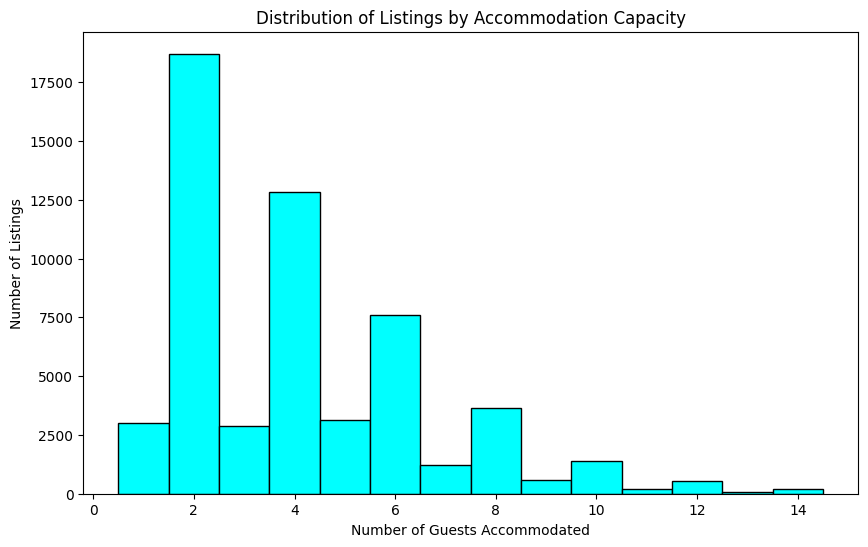

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(combined['accommodates'], bins=range(1, combined['accommodates'].max()), edgecolor = 'black', align = 'left', color = 'aqua')
plt.xlabel('Number of Guests Accommodated')
plt.ylabel('Number of Listings')
plt.title('Distribution of Listings by Accommodation Capacity')
plt.show()

Although appearing basic and simple, there are some insights to be learned from the distribution of listings by accommodation capacity. We see that the most common listings are for 2 guests, 4 guests, 6 guests etc, for even number of guests which decrease at an exponential rate. We could probably extrapolate this from the idea of bedrooms naturally sleep guests in pairs. However, this raises an interesting question for Airbnb hosts: Should we strategically list our capacity around even numbers? Will a property that can accommodate 4 guests (as opposed to 5) have a better booking rate? Or is the number not meaningful? We will look at this later on.

### Host Information

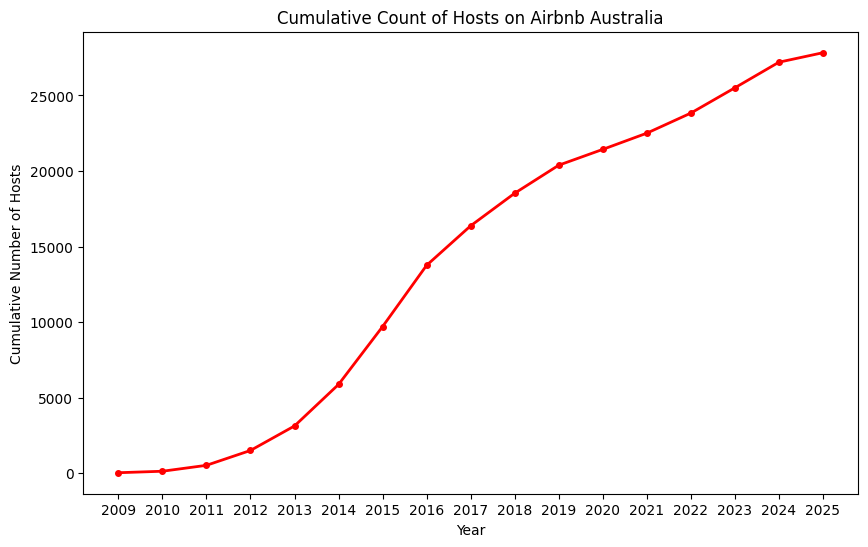

Text(0.5, 1.0, 'Distribution of Airbnb Hosts across Australia')

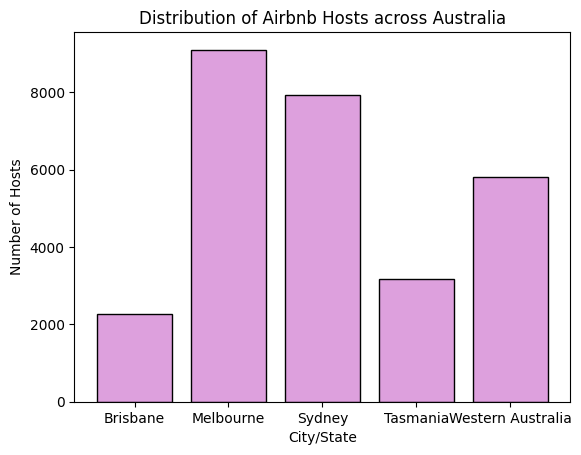

In [28]:
cumulative = combined.groupby('host_since_year')['host_id'].nunique().cumsum()

plt.figure(figsize=(10, 6))
plt.plot(cumulative.index, cumulative.values, color= 'red', linewidth= 2, marker= 'o', markersize= 4)
plt.xlabel('Year')
plt.ylabel('Cumulative Number of Hosts')
plt.title('Cumulative Count of Hosts on Airbnb Australia')
plt.xticks(cumulative.index)
plt.show()

host_counts = combined.groupby('city')['host_id'].nunique()

plt.bar(host_counts.index, host_counts.values, color = 'plum', edgecolor = 'black')
plt.xlabel('City/State')
plt.ylabel('Number of Hosts')
plt.title('Distribution of Airbnb Hosts across Australia')

The cumulative count of hosts on Airbnb Australia shows explosive growth between 2013 to 2016, reflecting the period of mainstream adoption where the platform grew rapidly in both awareness and popularity. Post 2016, the curve begins to flatten, with noticeable slowdown around 2020 and 2021 likely attributable to the impact of COVID-19. While growth has resumed since, it has not returned to the pace of earlier  years - which could indicate to us that the Australian Airbnb market is approaching saturation, or more simply, that the pool of potential new hosts is shrinking as adoption rate matures. Either way, it suggests that future growth in the platform will be increasingly reliant on existing hosts and their listings rather than new hosts. 


# Question Time!

### What drives price and revenue across listing types?

In this section, we  will explore the key factors and listing characteristics that influence both the price and estimated revenue for a listing

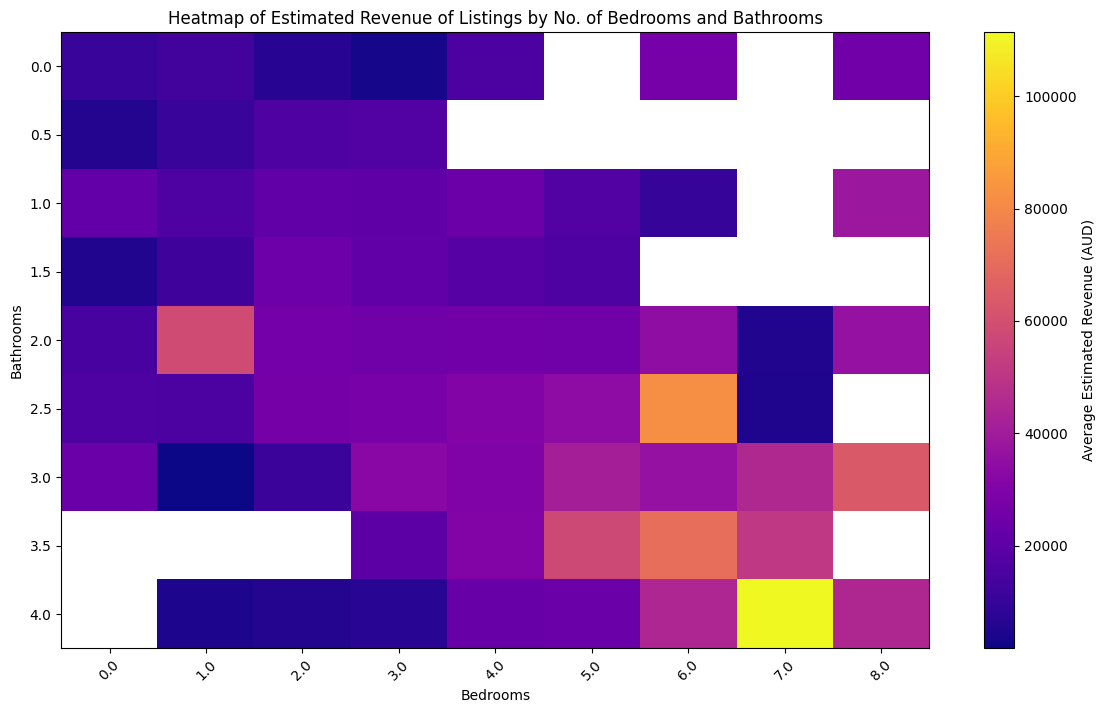

In [29]:
heatmap = df.pivot_table(values = 'estimated_revenue', index = 'bathrooms', columns = 'bedrooms', aggfunc = 'mean')
heatmap = heatmap.loc[heatmap.index <= 4, heatmap.columns <= 8] # Limit the heatmap to a maximum of 8 bedrooms and 4 bathrooms for better visualisation

plt.figure(figsize=(14, 8))
plt.imshow(heatmap, cmap= 'plasma', aspect= 'auto')

plt.xticks(ticks=range(len(heatmap.columns)), labels=heatmap.columns, rotation=45)
plt.yticks(ticks=range(len(heatmap.index)), labels=heatmap.index)
plt.title('Heatmap of Estimated Revenue of Listings by No. of Bedrooms and Bathrooms')
plt.colorbar(label='Average Estimated Revenue (AUD)')
plt.xlabel('Bedrooms')
plt.ylabel('Bathrooms')

plt.show()


For Airbnb listings in Australia, it appears that the general trend is that the more bedrooms and bathrooms, the higher the estimated revenue, though this is not entirely linear. 

One key point worth noting is that some high revenue generating cells in the heat map such as the yellow 7 bedroom and 4 bathrooms listing may only have a handful of listings. As such, it may simply be an outlier rather than  a reliable average across various listings. Let's us next overlay the number of listings for each cell.

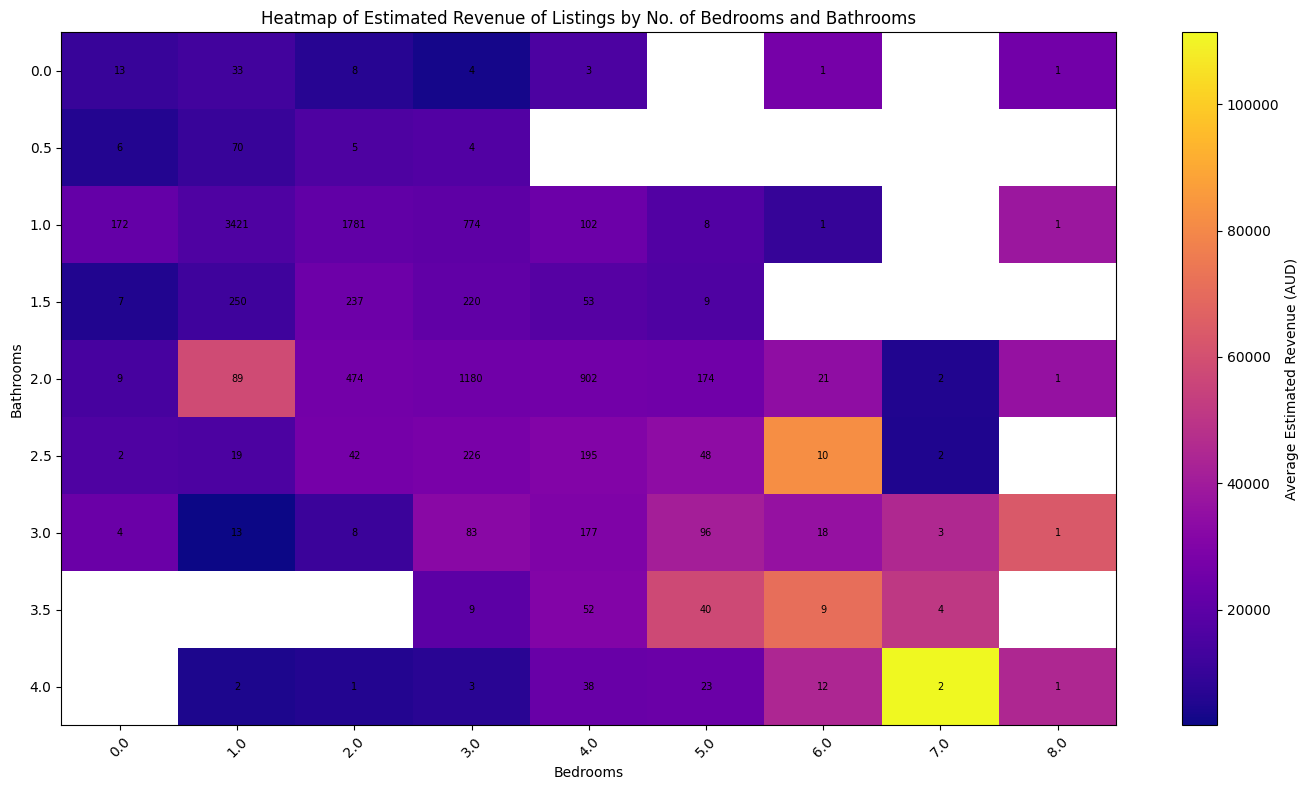

In [30]:
count_map = df.pivot_table(values = 'estimated_revenue', index = 'bathrooms', columns = 'bedrooms', aggfunc = 'count')
count_map = count_map.loc[count_map.index <= 4, count_map.columns <= 8] # Limit the heatmap to a maximum of 8 bedrooms and 4 bathrooms for better visualisation

plt.figure(figsize=(14, 8))
plt.imshow(heatmap, cmap = 'plasma', aspect = 'auto')

for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        count = count_map.iloc[i, j]
        if not np.isnan(count):
            plt.text(j, i, int(count), ha='center', va='center', fontsize=7, color='black')

plt.xticks(ticks=range(len(heatmap.columns)), labels=heatmap.columns, rotation=45)
plt.yticks(ticks=range(len(heatmap.index)), labels=heatmap.index)
plt.title('Heatmap of Estimated Revenue of Listings by No. of Bedrooms and Bathrooms')
plt.colorbar(label='Average Estimated Revenue (AUD)')
plt.xlabel('Bedrooms')
plt.ylabel('Bathrooms')
plt.tight_layout()
plt.show()


From this updated heatmap, we see that the bulk of listings are heavily concentrated in the 1-2 bedroom and 1 bathroom range, suggesting that the Australian Airbnb market is dominated by smaller properties.

While larger bedroom and bathroom combinations appear to generate higher estimated revenue, these cells contain significantly fewer listings. As such, these figures should be interpreted with caution, as they may not be representative of the broader market and be skewed. Prospective Airbnb hosts should therefore not rely solely on property size and combination of bathrooms and bedrooms as an indicator of revenue potential. 

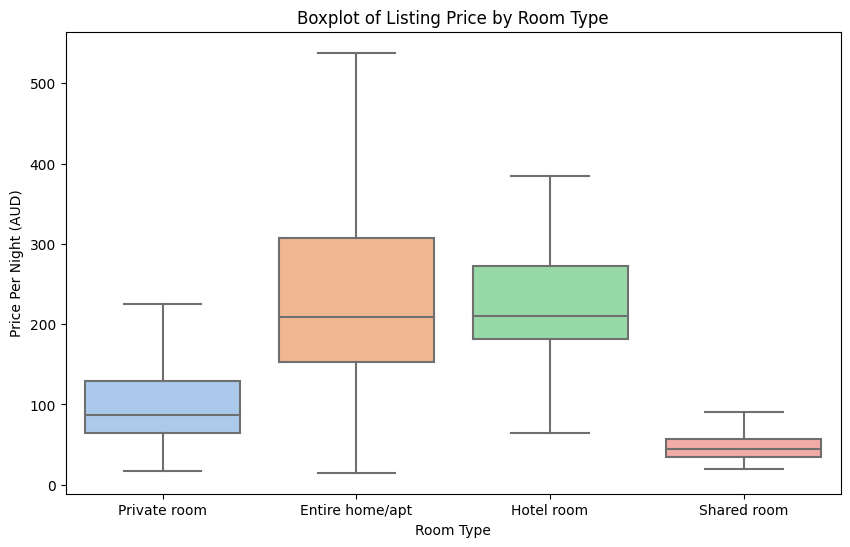

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x = 'room_type', y = 'price', data = combined, showfliers = False, palette = 'pastel')
plt.title('Boxplot of Listing Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price Per Night (AUD)')
plt.show()

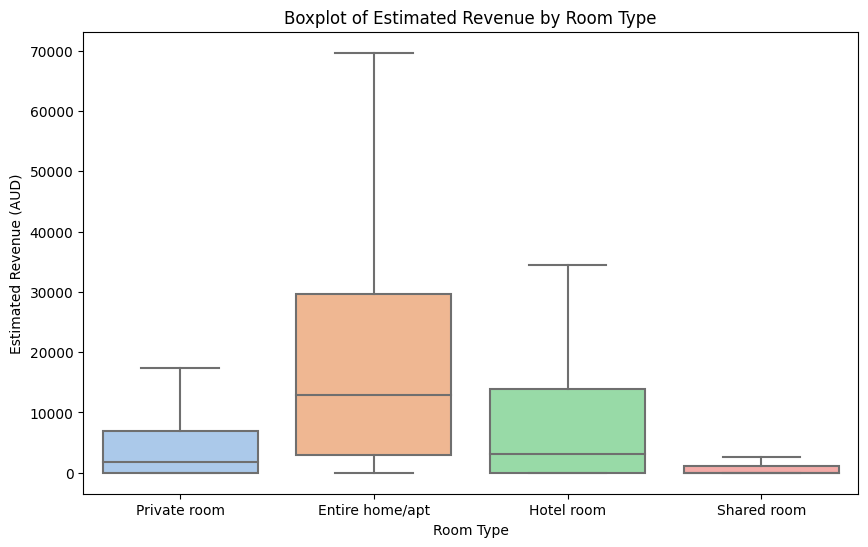

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(x = 'room_type', y = 'estimated_revenue', data = combined, showfliers = False, palette = 'pastel')
plt.title('Boxplot of Estimated Revenue by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Estimated Revenue (AUD)')
plt.show()

The two boxplot graphs reveal an important distinction between listing price and actual revenue by room type. While entire homes/apartments and hotels rooms have near-identical median prices (around ~$220 per night), their revenue outcomes differ drastically. Entire homes and apartments generate significantly higher revenue (by estimate), with the upper quartile reaching around $30,000 AUD per year and top performers even earning around $70,000! Hotel rooms, despite their comparable nightly rate, show much lower revenue, suggesting poor occupancy and that they are being effectively outcompeted on the Airbnb platform by entire home listings that offer greater space and autonomy at the same listing price. 

Perhaps the most important point here is the wide interquartile range for entire homes and apartments, spanning between 3,000 and 30,000 annually. This wide spread indicates that listing type alone does not guarantee strong revenue performance and that there are variation driven by other factors that nightly rates cannot explain. We will try to pinpoint this in our future analysis.

### Which neighbourhoods perform the best?

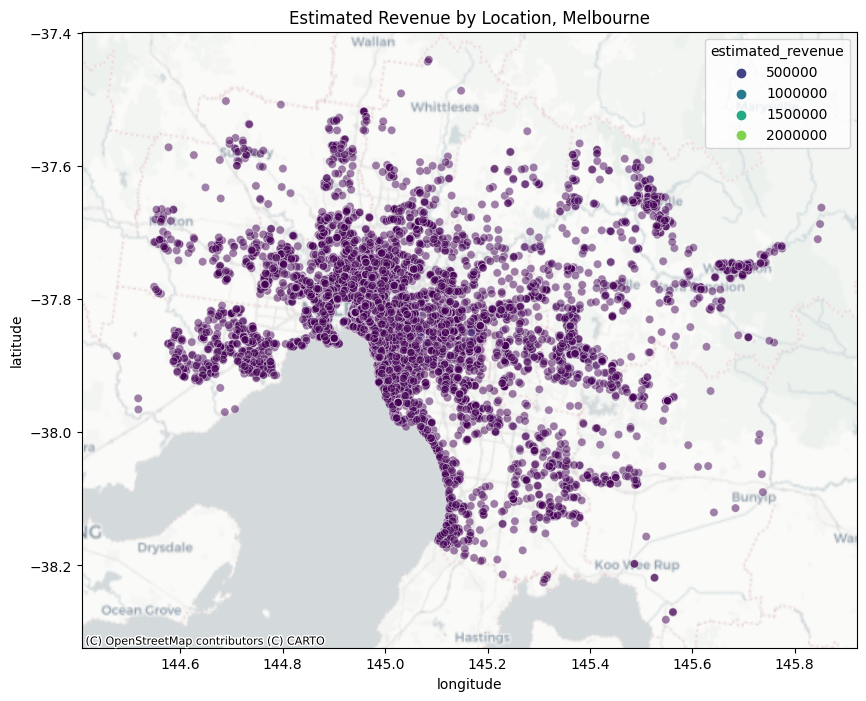

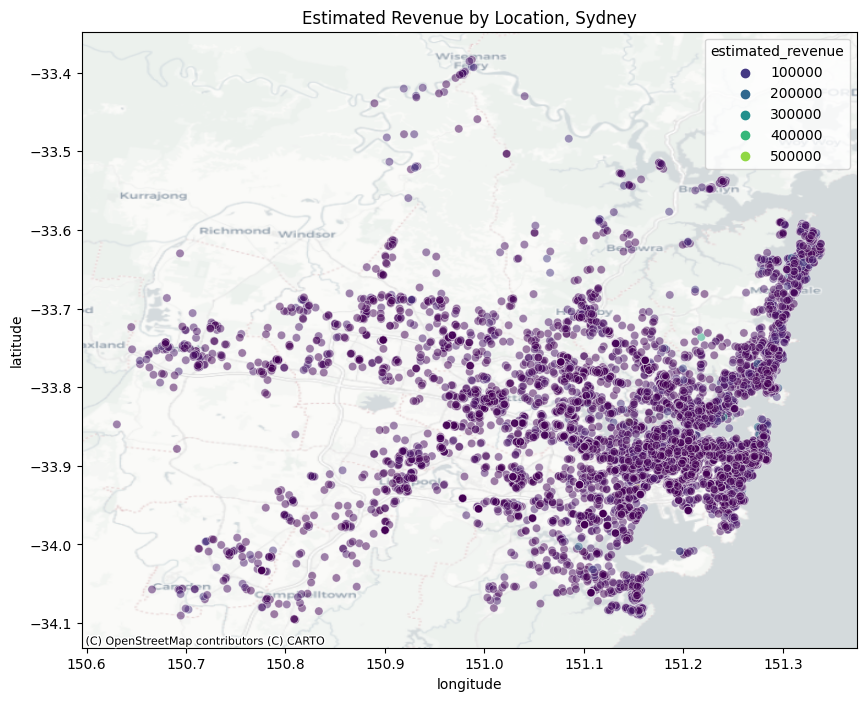

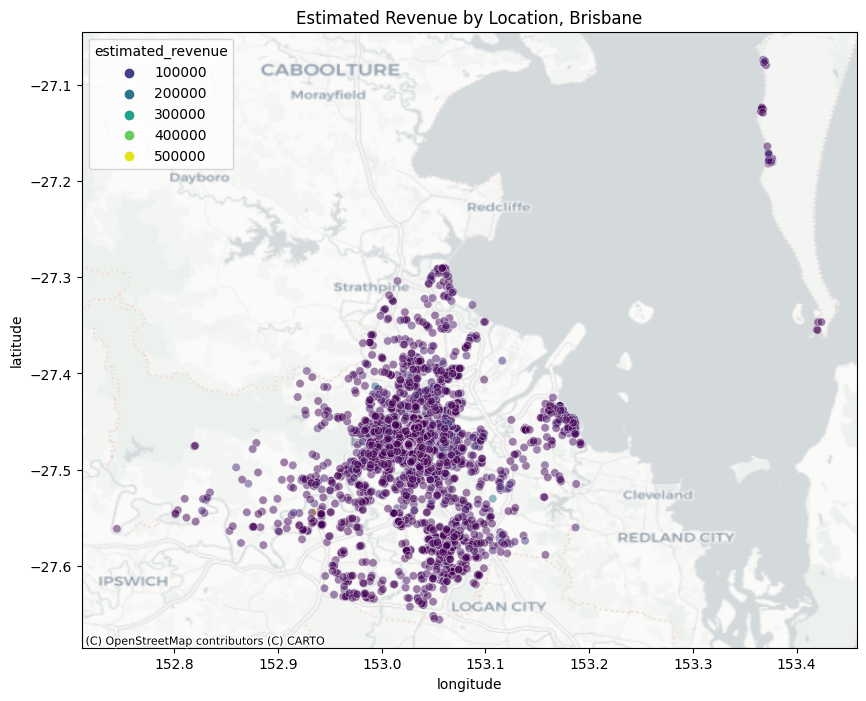

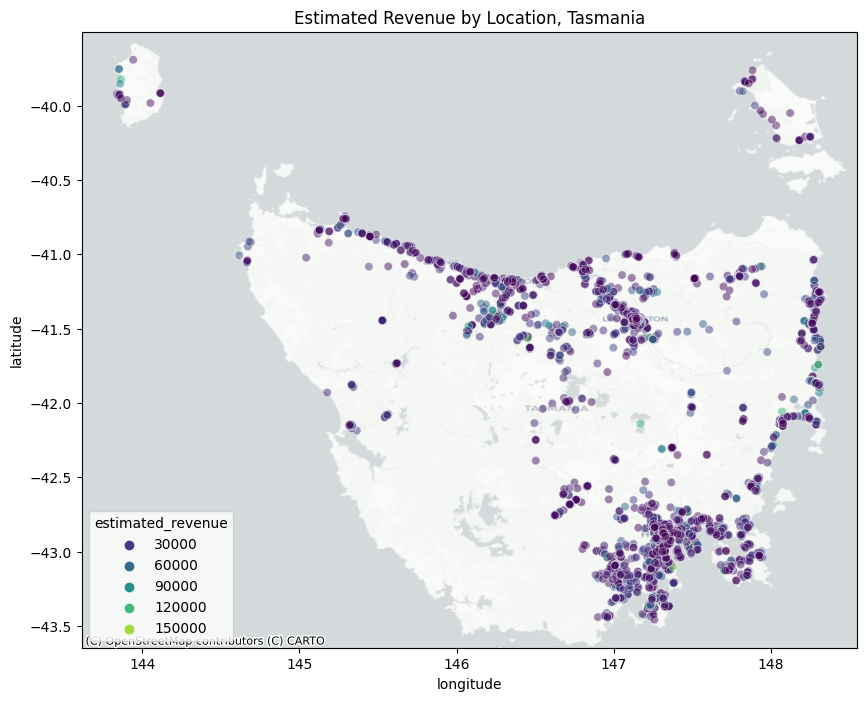

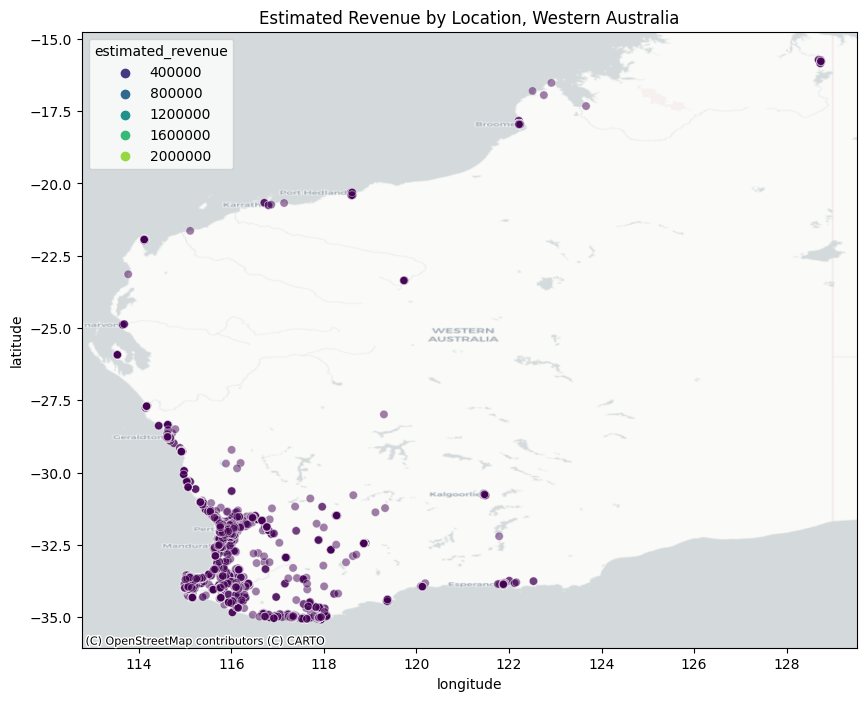

In [33]:
for name, city in major_cities.items():
    city = city[city['estimated_revenue'] > 0] # Filter out listings with 0 estimated revenue for better visualisation

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.scatterplot(data=city, 
                    x = 'longitude', 
                    y = 'latitude', 
                    hue = 'estimated_revenue',
                    palette = 'viridis', 
                    alpha = 0.5, 
                    ax = ax)

    ctx.add_basemap(
        ax, 
        crs = 'EPSG:4326', 
        source = ctx.providers.CartoDB.Positron # A clean, light-colored map
    )

    ax.set_title(f"Estimated Revenue by Location, {name}")
    plt.show()

Across all the cities and states, coastal and inner-city locations dominate revenue performance - this is most prominent in Melbourne CBD and Sydney's eastern coastline. Tasmania stands out for having relatively higher revenue per listing despite its smaller market size, suggesting less competition and a more premium and niche demand.

Top suburbs in each city/state\
Melbourne: Melbourne CBD, St. Kilda\
Sydney: Bondi, Randwick, Northern Beaches\
Brisbane: Inner Brisbane, South Brisbane\
Tasmania: Hobart areas and northeast towns\
Western Australia: Perth inner suburbs, Fremantle

### Do host characteristics affect performance?


Here, we will look into host characteristics - including number of listings, tenure on the platform and guest ratings.  We will examine whether these characteristics influence revenue performance and listing price.


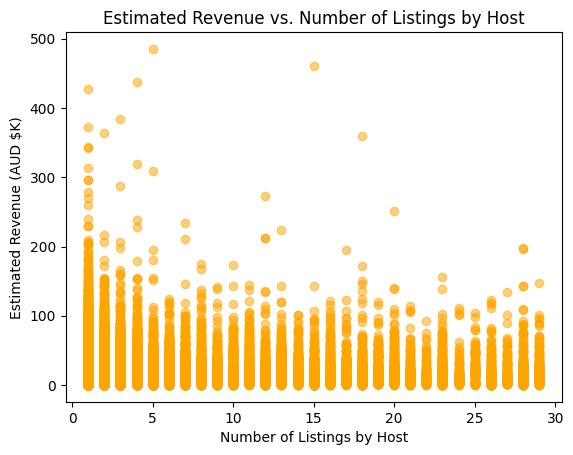

In [34]:


combined = pd.concat(major_cities.values(), ignore_index=True) # Combine all the cities into one dataset for easier analysis and visualisation
combined.groupby('host_id')
combined['host_listings_count'] = combined['host_listings_count'].fillna(0).astype(int) 
combined['estimated_revenue'] = combined['estimated_revenue'].fillna(0).astype(int)
combined['host_since'] = pd.to_datetime(combined['host_since'])
combined = combined[combined['estimated_revenue'] > 0] # For this plot, only include listings with estimated renuve between 500,000 and 0 AUD
combined = combined[combined['estimated_revenue'] < 500000] 
combined = combined[combined['host_listings_count'] > 0]  # Only include hosts with at least 1 listing to avoid skewing the plot with hosts that have no listings
combined = combined[combined['host_listings_count'] < 30]  # Max of 30 listings


plt.scatter(combined['host_listings_count'], combined['estimated_revenue'] / 1000, alpha=0.5, color = 'orange')
plt.xlabel('Number of Listings by Host')
plt.ylabel('Estimated Revenue (AUD $K)')
plt.title('Estimated Revenue vs. Number of Listings by Host')
plt.show()

This scatterplot explores the relationship between the number of listing per host and their estimated revenue. Interestingly, hosts with fewer listings, especially those with 1-2 properties display the widest range of revenue, with some outearning hosts who manage far more properties. This suggests that having more listings does not necessarily translate to higher revenue. 

Another point is that as the number of listings increases, revenue seems to flatten. This could reflect a quality issue, where hosts managing many properties may struggle to maintain standards, leading to poorer reviews and lower occupancy. Alternatively, guests may perceive hosts with a large number of listings as too commercial and less personal. 

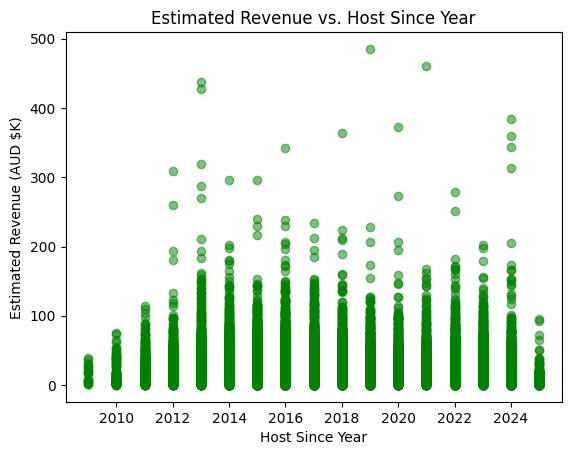

In [35]:
plt.scatter(combined['host_since'].dt.year, combined['estimated_revenue'] / 1000, alpha=0.5, color = 'green')
plt.xlabel('Host Since Year')
plt.ylabel('Estimated Revenue (AUD $K)')
plt.title('Estimated Revenue vs. Host Since Year')
plt.show()



There is no apparent relationship between host tenure and estimated revenue. Unsurprisingly, hosts who joined in 2025 show the lowest revenue at least for hots in the last 10 years, as they have not yet had time to build reviews, reputation or optimise their listings yet. Beyond this, early account creation does not seem to have any meaningful advantage, their listings perform no better than those who joined more recently, say in 2021.

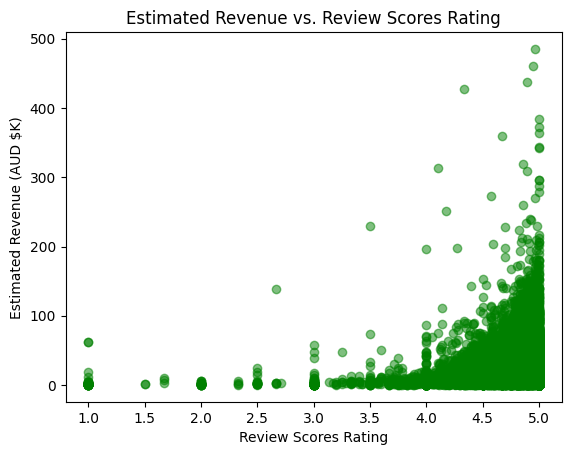

In [36]:
plt.scatter(combined['review_scores_rating'], combined['estimated_revenue'] / 1000, alpha=0.5, color = 'green')
plt.xlabel('Review Scores Rating')
plt.ylabel('Estimated Revenue (AUD $K)')
plt.title('Estimated Revenue vs. Review Scores Rating')
plt.show()

Finally, a clear pattern emerges! We see that review scores show the strongest relationship with estimated revenue of all the variables we have explored. Listings rated between 4.5 and 5.0 capture the majority of high-earning properties, while low-rated listings cluster near zero regardless of other factors. This reflects how paramount reviews are to guest decision-making on Airbnb. A highly rated listing builds trust, attracts more bookings, and draws higher prices, all of which lead into significantly greater revenue. 

Now, this begs the question: If greater revenue is correlated to better review score ratings? How do we get better reviews? For new hosts, there would be an element of luck. This being that the first few guests would set the tone for your entire ratings. For others, it comes down to the listing itself such as accurate listing description, competitive pricing and a well-maintained and designed property. 

It is worth noting that a high review scores rating alone does not guarantee high revenue - as we can see the concentration of perfect-rated listings still earning very little. However, what remains is still a strong positive correlation; that a high review score is a necessary but not sufficient condition for maximising revenue for listings on Airbnb in the Australian market.

## Can we predict revenue for a listing?

Here, we will build a machine learning regression model to predict estimated revenue for Airbnb listings across Australia. Using xGBoost, which is a powerful algorithm that learns from patterns in data by building from small decision trees upwards and correct the mistakes of the previous, the model aims to predict how much revenue a listing is likely to generate based on different characteristics

In [118]:

# Change categorical columns using LabelEncoder
le = LabelEncoder()

combined['room_type'] = le.fit_transform(combined['room_type'])
combined['city'] = le.fit_transform(combined['city'])
combined['instant_bookable'] = le.fit_transform(combined['instant_bookable'])
combined = combined[combined['estimated_revenue'] < combined['estimated_revenue'].quantile(0.95)] # Remove outliers

target = 'estimated_revenue'
features = ['host_listings_count', 
            'room_type', 
            'accommodates', 
            'bedrooms', 
            'number_of_reviews', 
            'review_scores_rating', 
            'city', 
            'price',  
            'availability_365',
            'bathrooms',
            'beds',
            'instant_bookable',
            'latitude',
            'longitude']

X = combined[features]
Y = np.log1p(combined[target]) # Log transform the target variable the distribution to be more normal for better performance of the regression model

X_Train, X_Test, Y_Train, Y_Test = sklearn.model_selection.train_test_split(X, Y, test_size = 0.2, random_state = 88) # 80% training and 20% testing

xGBoostModel =  XGBRegressor(n_estimators = 500, learning_rate = 0.05, max_depth = 6, random_state = 88)
xGBoostModel.fit(X_Train, Y_Train)

# Predict using the trained model on the test set
Y_Pred = xGBoostModel.predict(X_Test)

# Evaluate
rmse = sklearn.metrics.root_mean_squared_error(Y_Test, Y_Pred)
mae = sklearn.metrics.mean_absolute_error(Y_Test, Y_Pred)
r2 = sklearn.metrics.r2_score(Y_Test, Y_Pred)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2 Score): {r2}")


Root Mean Squared Error (RMSE): 0.20042751537538991
R-squared (R2 Score): 0.6611068336292762


Through a combination of feature changes, removing outlier and taking the log transformation of the target variable of estimated revenue, our xGBoost regression is able to explain 66.1% of the variance in Airbnb revenue across Australian listings in Sydney, Melbourne, Brisbane, Tasmania and Western Australia. Overall, the model suggests that a combination of the listing characteristics such as price, review ratings, room type and availability are all meaningful predictors for the estimated revenue of a listing.